In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#Librerias

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.optimizers import RMSprop, Adam, SGD, Nadam, AdamW
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
import tensorflow as tf

import json

import pickle

from itertools import combinations

from collections import Counter


#Ruta para guardar/importar archivos

In [ ]:
ruta='/content/drive/MyDrive/Colab Notebooks/Tesis/Codigos/'

#Preprocesamiento de la base

In [ ]:
#@title Funcion
def preparar_pipeline(vars_keep, input_length, output_length,var_n):

    import numpy as np
    from sklearn.preprocessing import MinMaxScaler

    col_ref = vars_keep.index(var_n)

    for c in countries:
      name = c.replace(" ", "_")
      globals()[f"base_{name}"] = df[df["country"] == c]

    for name in globals():
      if name.startswith("base_"):
          globals()[name] = globals()[name].sort_values(by="date")

    # Años
    ano_ini_entre = 1983
    ano_fin_entre = 2010
    ano_ini_val = 2011
    ano_fin_val = 2016
    ano_ini_test = 2017
    ano_fin_test = 2022

    anos_entre = ano_fin_entre - ano_ini_entre + 1
    anos_vali = ano_fin_val - ano_ini_val + 1
    anos_test = ano_fin_test - ano_ini_test + 1

    # Selección de columnas
    for name in globals():
        if name.startswith("base_"):
            globals()[name] = globals()[name][vars_keep]

    # ---------------- TRAIN ----------------
    for name in list(globals().keys()):
        if name.startswith("base_"):

            x_train, y_train = [], []
            array = globals()[name].to_numpy()

            for i in range(anos_entre - input_length - output_length + 1):

                x_train.append(array[i:i+input_length])

                y_train.append(
                    array[i+input_length:i+input_length+output_length, -1]
                    .reshape(output_length, 1)
                )

            clean = name.replace("base_", "")

            globals()[f"x_train_{clean}"] = np.array(x_train)
            globals()[f"y_train_{clean}"] = np.array(y_train)

    # ---------------- VALID ----------------
    for name in list(globals().keys()):
        if name.startswith("base_"):

            x_val, y_val = [], []
            array = globals()[name].to_numpy()

            for i in range(
                anos_entre - input_length,
                anos_entre + anos_vali - output_length - input_length + 1
            ):

                x_val.append(array[i:i+input_length])

                y_val.append(
                    array[i+input_length:i+input_length+output_length, -1]
                    .reshape(output_length, 1)
                )

            clean = name.replace("base_", "")

            globals()[f"x_val_{clean}"] = np.array(x_val)
            globals()[f"y_val_{clean}"] = np.array(y_val)

    # ---------------- TEST ----------------
    for name in list(globals().keys()):
        if name.startswith("base_"):

            x_test, y_test = [], []
            array = globals()[name].to_numpy()

            for i in range(
                anos_entre + anos_vali - input_length,
                anos_entre + anos_vali + anos_test - output_length - input_length + 1
            ):

                x_test.append(array[i:i+input_length])

                y_test.append(
                    array[i+input_length:i+input_length+output_length, -1]
                    .reshape(output_length, 1)
                )

            clean = name.replace("base_", "")

            globals()[f"x_test_{clean}"] = np.array(x_test)
            globals()[f"y_test_{clean}"] = np.array(y_test)

    # ---------------- SCALERS ----------------
    for name in list(globals().keys()):
        if name.startswith("base_"):
            clean = name.replace("base_", "")
            globals()[f"scaler_{clean}"] = [
                MinMaxScaler(feature_range=(-1, 1))
                for _ in range(len(vars_keep))
            ]

    # ---------------- CREAR ARRAYS VACÍOS ----------------
    for name in list(globals().keys()):

        if name.startswith("x_train"):
            clean = name.replace("x_train", "")
            globals()[f"x_tr{clean}"] = np.zeros(globals()[name].shape)

        if name.startswith("y_train"):
            clean = name.replace("y_train", "")
            globals()[f"y_tr{clean}"] = np.zeros(globals()[name].shape)

        if name.startswith("x_val"):
            clean = name.replace("x_val", "")
            globals()[f"x_vl{clean}"] = np.zeros(globals()[name].shape)

        if name.startswith("y_val"):
            clean = name.replace("y_val", "")
            globals()[f"y_vl{clean}"] = np.zeros(globals()[name].shape)

        if name.startswith("x_test"):
            clean = name.replace("x_test", "")
            globals()[f"x_tst{clean}"] = np.zeros(globals()[name].shape)

        if name.startswith("y_test"):
            clean = name.replace("y_test", "")
            globals()[f"y_tst{clean}"] = np.zeros(globals()[name].shape)

    # ---------------- ESCALADO X TRAIN ----------------
    for name in list(globals().keys()):
        if name.startswith("x_train_"):

            clean = name.replace("x_train_", "")
            X = globals()[name]
            scalers = globals()[f"scaler_{clean}"]

            for i in range(len(vars_keep)):

                data = X[:, :, i].reshape(-1, 1)
                scaled = scalers[i].fit_transform(data)

                globals()[f"x_tr_{clean}"][:, :, i] = scaled.reshape(
                    X[:, :, i].shape
                )

    # ---------------- ESCALADO X VALID ----------------
    for name in list(globals().keys()):
        if name.startswith("x_val_"):

            clean = name.replace("x_val_", "")
            X = globals()[name]
            scalers = globals()[f"scaler_{clean}"]

            for i in range(len(vars_keep)):

                data = X[:, :, i].reshape(-1, 1)
                scaled = scalers[i].transform(data)

                globals()[f"x_vl_{clean}"][:, :, i] = scaled.reshape(
                    X[:, :, i].shape
                )

    # ---------------- ESCALADO X TEST ----------------
    for name in list(globals().keys()):
        if name.startswith("x_test_"):

            clean = name.replace("x_test_", "")
            X = globals()[name]
            scalers = globals()[f"scaler_{clean}"]

            for i in range(len(vars_keep)):

                data = X[:, :, i].reshape(-1, 1)
                scaled = scalers[i].transform(data)

                globals()[f"x_tst_{clean}"][:, :, i] = scaled.reshape(
                    X[:, :, i].shape
                )

    # ---------------- ESCALADO Y ----------------
    for name in list(globals().keys()):
        if name.startswith("y_train_"):

            clean = name.replace("y_train_", "")
            X = globals()[name]
            scalers = globals()[f"scaler_{clean}"]

            data = X[:, :, 0].reshape(-1, 1)
            scaled = scalers[col_ref].transform(data)

            globals()[f"y_tr_{clean}"][:, :, 0] = scaled.reshape(X[:, :, 0].shape)

    for name in list(globals().keys()):
        if name.startswith("y_val_"):

            clean = name.replace("y_val_", "")
            X = globals()[name]
            scalers = globals()[f"scaler_{clean}"]

            data = X[:, :, 0].reshape(-1, 1)
            scaled = scalers[col_ref].transform(data)

            globals()[f"y_vl_{clean}"][:, :, 0] = scaled.reshape(X[:, :, 0].shape)

    for name in list(globals().keys()):
        if name.startswith("y_test_"):

            clean = name.replace("y_test_", "")
            X = globals()[name]
            scalers = globals()[f"scaler_{clean}"]

            data = X[:, :, 0].reshape(-1, 1)
            scaled = scalers[col_ref].transform(data)

            globals()[f"y_tst_{clean}"][:, :, 0] = scaled.reshape(X[:, :, 0].shape)

    # ---------------- BASES TOTALES ----------------
    x_total_train = np.empty((0, globals()["x_tr_Australia"].shape[1], globals()["x_tr_Australia"].shape[2]))

    for name in list(globals().keys()):
        if name.startswith("x_tr_"):
            x_total_train = np.concatenate((x_total_train, globals()[name]), axis=0)

    y_total_train = np.empty((0, globals()["y_tr_Australia"].shape[1], globals()["y_tr_Australia"].shape[2]))

    for name in list(globals().keys()):
        if name.startswith("y_tr_"):
            y_total_train = np.concatenate((y_total_train, globals()[name]), axis=0)

    x_total_valid = np.empty((0, globals()["x_vl_Australia"].shape[1], globals()["x_vl_Australia"].shape[2]))

    for name in list(globals().keys()):
        if name.startswith("x_vl_"):
            x_total_valid = np.concatenate((x_total_valid, globals()[name]), axis=0)

    y_total_valid = np.empty((0, globals()["y_vl_Australia"].shape[1], globals()["y_vl_Australia"].shape[2]))

    for name in list(globals().keys()):
        if name.startswith("y_vl_"):
            y_total_valid = np.concatenate((y_total_valid, globals()[name]), axis=0)

    x_total_test = np.empty((0, globals()["x_tst_Australia"].shape[1], globals()["x_tst_Australia"].shape[2]))

    for name in list(globals().keys()):
        if name.startswith("x_tst_"):
            x_total_test = np.concatenate((x_total_test, globals()[name]), axis=0)

    y_total_test = np.empty((0, globals()["y_tst_Australia"].shape[1], globals()["y_tst_Australia"].shape[2]))

    for name in list(globals().keys()):
        if name.startswith("y_tst_"):
            y_total_test = np.concatenate((y_total_test, globals()[name]), axis=0)

    return (
        x_total_train,
        y_total_train,
        x_total_valid,
        y_total_valid,
        x_total_test,
        y_total_test
    )

#Funciones extras

In [ ]:
#@title Detectar picos y valles
def find_peaks_valleys(series):
    peaks = []
    valleys = []

    for i in range(1, len(series)-1):
        if series[i-1] < series[i] > series[i+1]:
            peaks.append(i)
        elif series[i-1] > series[i] < series[i+1]:
            valleys.append(i)

    return peaks, valleys

In [ ]:
#@title Ordenar picos y valles
def build_events(series):
    peaks, valleys = find_peaks_valleys(series)

    events = []
    for i in peaks:
        events.append(("peak", i, series[i]))
    for i in valleys:
        events.append(("valley", i, series[i]))

    # ordenar por tiempo
    events.sort(key=lambda x: x[1])

    return events

In [ ]:
#@title Calculo transiciones
def compute_transitions(events):
    results = []

    for i in range(len(events)-1):
        type1, t1, v1 = events[i]
        type2, t2, v2 = events[i+1]

        delta_time = t2 - t1
        delta_value = v2 - v1

        results.append({
            "from": type1,
            "to": type2,
            "time_diff": delta_time,
            "value_diff": delta_value
        })

    return results

In [ ]:
#@title Maximo de picos y minimo de valles
def peak_valley_stats(series):
    peaks, valleys = find_peaks_valleys(series)

    peak_values = [series[i] for i in peaks]
    valley_values = [series[i] for i in valleys]

    max_peak = max(peak_values) if peak_values else None
    min_valley = min(valley_values) if valley_values else None

    return max_peak, min_valley

In [ ]:
#@title Historial de picos y valles (tiempo y cambio)
def extract_dynamics(series):
    peaks, valleys = find_peaks_valleys(series)

    # construir eventos ordenados
    events = []
    for i in peaks:
        events.append(("peak", i, series[i]))
    for i in valleys:
        events.append(("valley", i, series[i]))

    events.sort(key=lambda x: x[1])

    # contenedores
    peak_to_valley_time = []
    valley_to_peak_time = []

    peak_to_valley_drop = []
    valley_to_peak_rise = []

    # recorrer eventos consecutivos
    for i in range(len(events)-1):
        type1, t1, v1 = events[i]
        type2, t2, v2 = events[i+1]

        dt = t2 - t1
        dv = v2 - v1

        if type1 == "peak" and type2 == "valley":
            peak_to_valley_time.append(dt)
            peak_to_valley_drop.append(v1 - v2)  # caída positiva

        elif type1 == "valley" and type2 == "peak":
            valley_to_peak_time.append(dt)
            valley_to_peak_rise.append(v2 - v1)  # subida positiva

    return (
        peak_to_valley_time,
        valley_to_peak_time,
        peak_to_valley_drop,
        valley_to_peak_rise
    )

#Seleccion de parametros

In [ ]:
inicio=input_length=10
final=output_length=3
total=inicio+final

vars_keep = ["GDP_growth"]

#Importar base de datos

In [ ]:
df=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Tesis/base_datos.csv')
df

,country,date,GDP_cnstn,GDP_growth,GDP_cnstn_usd,GDP_pp_usd,GDP_pp_LCU,Inflatn,forgn_invst,forgn_invst_gdp,Fin_consum,Fin_consum_govern,Ext_balnce_g_s,Fin_consum_hous,Unmploy,Labor_part,GDP_usd
0,Australia,2022,2.552248e+12,4.253046,1.592358e+12,61200.458896,98092.754060,7.199544,6.870942e+10,4.052153,71.071701,22.017954,5.228418,49.053747,3.728,66.846,1.695628e+12
1,Australia,2021,2.448128e+12,2.006948,1.527397e+12,59465.535671,95312.000446,3.060670,3.145306e+10,2.015424,73.318371,22.366947,3.801393,50.951424,5.022,66.056,1.560617e+12
2,Australia,2020,2.399962e+12,-0.133532,1.497346e+12,58377.767052,93568.513198,1.865834,1.797684e+10,1.348260,74.278610,21.813861,3.376511,52.464749,6.394,64.980,1.333336e+12
3,Australia,2019,2.403171e+12,2.194017,1.499348e+12,59181.299790,94856.424118,3.476600,3.874513e+10,2.770776,74.579592,20.289384,2.123277,54.290208,5.143,66.052,1.398350e+12
4,Australia,2018,2.351577e+12,2.874170,1.467158e+12,58772.706315,94201.526099,1.846176,6.068664e+10,4.234508,75.393593,19.942302,0.051922,55.451291,5.345,65.746,1.433145e+12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
675,United States,1987,9.627608e+12,3.454630,8.849219e+12,36523.404486,39736.051302,2.477388,6.323500e+10,1.302414,79.361511,16.001207,-2.981742,63.360304,6.200,65.600,4.855215e+12
676,United States,1986,9.306116e+12,3.462655,8.553720e+12,35620.759359,38754.008320,2.013893,3.094600e+10,0.675731,79.138843,16.114595,-2.879468,63.024248,7.000,65.300,4.579631e+12
677,United States,1985,8.994662e+12,4.169575,8.267447e+12,34748.266874,37804.770246,3.162525,9.630000e+09,0.221942,78.439421,15.917109,-2.627761,62.522312,7.200,64.800,4.338979e+12
678,United States,1984,8.634635e+12,7.236453,7.936527e+12,33654.307930,36614.585231,3.607879,2.523000e+10,0.624874,77.448433,15.720377,-2.544251,61.728056,7.500,64.400,4.037613e+12


##Creo arrays

In [ ]:
countries = df["country"].unique()
print(countries.shape)
countries

(17,)


array(['Australia', 'Austria', 'Belgium', 'Canada', 'Germany', 'Denmark',
       'Spain', 'France', 'United Kingdom', 'Greece',
       'Hong Kong SAR, China', 'Ireland', 'Italy', 'Japan', 'Korea, Rep.',
       'Norway', 'United States'], dtype=object)

In [ ]:
#Datos
x_total_train, y_total_train, x_total_valid, y_total_valid, x_total_test, y_total_test =preparar_pipeline(vars_keep,input_length,output_length,vars_keep[0])

#Graficos

##Train

Cambio shape

In [ ]:
print(x_total_train.shape)
X = x_total_train.squeeze(-1)
print(X.shape)

(272, 10, 1)
(272, 10)


In [ ]:
ptv_time_all = []
vtp_time_all = []
ptv_drop_all = []
vtp_rise_all = []

for row in X:
    ptv_t, vtp_t, ptv_d, vtp_r = extract_dynamics(row)

    ptv_time_all.extend(ptv_t)
    vtp_time_all.extend(vtp_t)
    ptv_drop_all.extend(ptv_d)
    vtp_rise_all.extend(vtp_r)

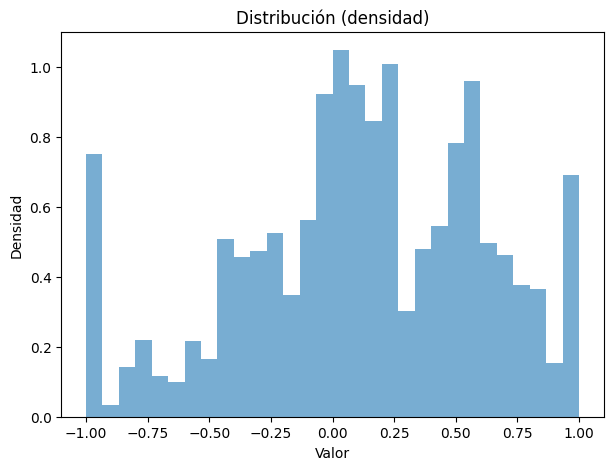

In [ ]:
#@title Distribución
all_values = X.flatten()

plt.figure(figsize=(7,5))

plt.hist(all_values, bins=30, density=True, alpha=0.6)

plt.title("Distribución (densidad)")
plt.xlabel("Valor")
plt.ylabel("Densidad")
plt.savefig(ruta+"densidad_train.png")

plt.show()

###Pico → Valle

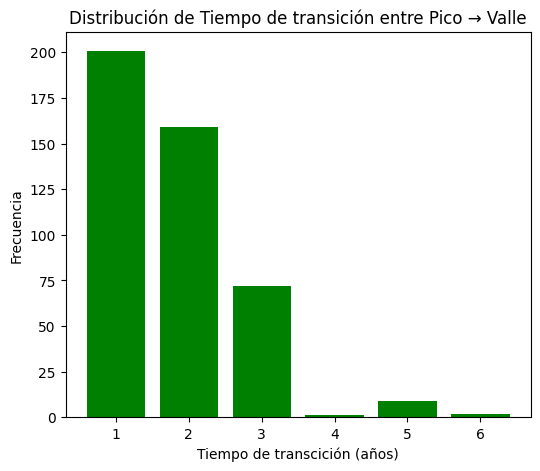

In [ ]:
#@title Tiempo Pico → Valle
# Contar frecuencias
frecuencias = Counter(ptv_time_all)

# Separar valores y conteos
valores = list(frecuencias.keys())
conteos = list(frecuencias.values())

# Crear gráfico de barras
plt.figure(figsize=(6,5))

plt.bar(valores, conteos, color='green')

plt.title("Distribución de Tiempo de transición entre Pico → Valle")
plt.xlabel("Tiempo de transcición (años)")
plt.ylabel("Frecuencia")
plt.xticks(valores)
plt.savefig(ruta+"tiempo_ptv_train.png")

plt.show()

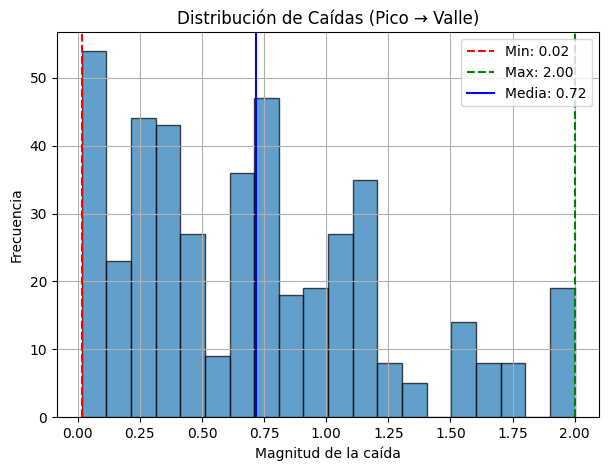

In [ ]:
#@title Caidas Pico → Valle
min_val = np.min(ptv_drop_all)
max_val = np.max(ptv_drop_all)
mean_val = np.mean(ptv_drop_all)

plt.figure(figsize=(7,5))

plt.hist(ptv_drop_all, bins=20, alpha=0.7, edgecolor='black')

# líneas de referencia
plt.axvline(min_val, color='red', linestyle='--', label=f'Min: {min_val:.2f}')
plt.axvline(max_val, color='green', linestyle='--', label=f'Max: {max_val:.2f}')
plt.axvline(mean_val, color='blue', linestyle='-', label=f'Media: {mean_val:.2f}')


plt.title("Distribución de Caídas (Pico → Valle)")
plt.xlabel("Magnitud de la caída")
plt.ylabel("Frecuencia")

plt.legend()
plt.grid(True)
plt.savefig(ruta+"caidas_ptv_train.png")

plt.show()

###Valle → Pico

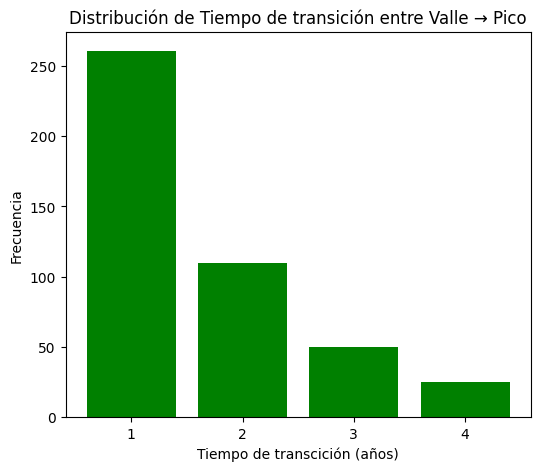

In [ ]:
#@title Tiempo  Valle → Pico
# Contar frecuencias
frecuencias = Counter(vtp_time_all)

# Separar valores y conteos
valores = list(frecuencias.keys())
conteos = list(frecuencias.values())

# Crear gráfico de barras
plt.figure(figsize=(6,5))

plt.bar(valores, conteos, color='green')

plt.title("Distribución de Tiempo de transición entre Valle → Pico")
plt.xlabel("Tiempo de transcición (años)")
plt.ylabel("Frecuencia")
plt.xticks(valores)
plt.savefig(ruta+"tiempo_vtp_train.png")

plt.show()

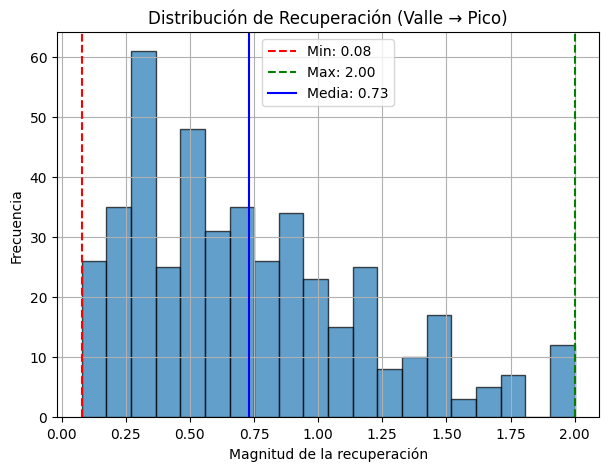

In [ ]:
#@title Recuperación Valle → Pico
min_val = np.min(vtp_rise_all)
max_val = np.max(vtp_rise_all)
mean_val = np.mean(vtp_rise_all)

plt.figure(figsize=(7,5))

plt.hist(vtp_rise_all, bins=20, alpha=0.7, edgecolor='black')

# líneas de referencia
plt.axvline(min_val, color='red', linestyle='--', label=f'Min: {min_val:.2f}')
plt.axvline(max_val, color='green', linestyle='--', label=f'Max: {max_val:.2f}')
plt.axvline(mean_val, color='blue', linestyle='-', label=f'Media: {mean_val:.2f}')


plt.title("Distribución de Recuperación (Valle → Pico)")
plt.xlabel("Magnitud de la recuperación")
plt.ylabel("Frecuencia")

plt.legend()
plt.grid(True)
plt.savefig(ruta+"recup_vtp_train.png")

plt.show()

##Validation

Cambio shape

In [ ]:
print(x_total_valid.shape)
X = x_total_valid.squeeze(-1)
print(X.shape)

(68, 10, 1)
(68, 10)


In [ ]:
ptv_time_all = []
vtp_time_all = []
ptv_drop_all = []
vtp_rise_all = []

for row in X:
    ptv_t, vtp_t, ptv_d, vtp_r = extract_dynamics(row)

    ptv_time_all.extend(ptv_t)
    vtp_time_all.extend(vtp_t)
    ptv_drop_all.extend(ptv_d)
    vtp_rise_all.extend(vtp_r)

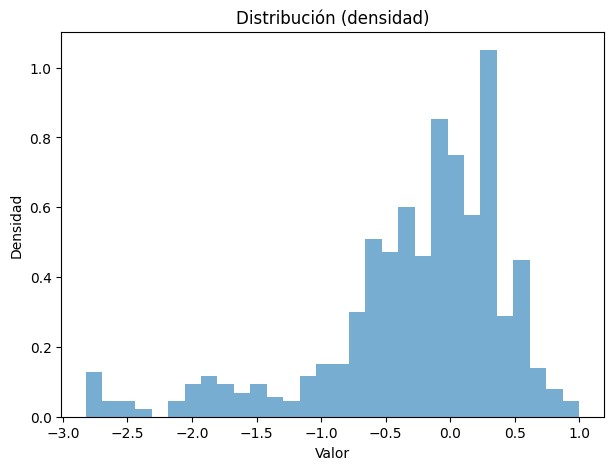

In [ ]:
#@title Distribución
all_values = X.flatten()

plt.figure(figsize=(7,5))

plt.hist(all_values, bins=30, density=True, alpha=0.6)

plt.title("Distribución (densidad)")
plt.xlabel("Valor")
plt.ylabel("Densidad")
plt.savefig(ruta+"densidad_valid.png")

plt.show()

###Pico → Valle

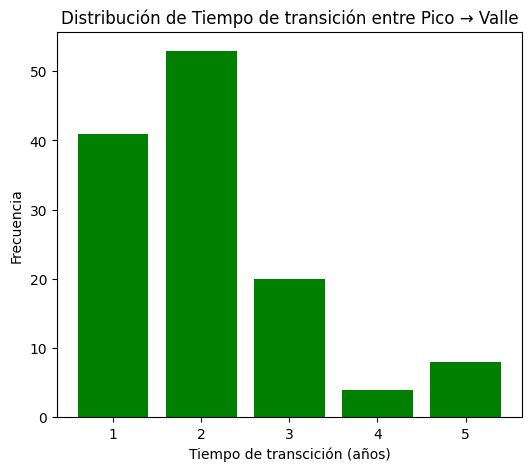

In [ ]:
#@title Tiempo Pico → Valle
# Contar frecuencias
frecuencias = Counter(ptv_time_all)

# Separar valores y conteos
valores = list(frecuencias.keys())
conteos = list(frecuencias.values())

# Crear gráfico de barras
plt.figure(figsize=(6,5))

plt.bar(valores, conteos, color='green')

plt.title("Distribución de Tiempo de transición entre Pico → Valle")
plt.xlabel("Tiempo de transcición (años)")
plt.ylabel("Frecuencia")
plt.xticks(valores)
plt.savefig(ruta+"tiempo_ptv_valid.png")

plt.show()

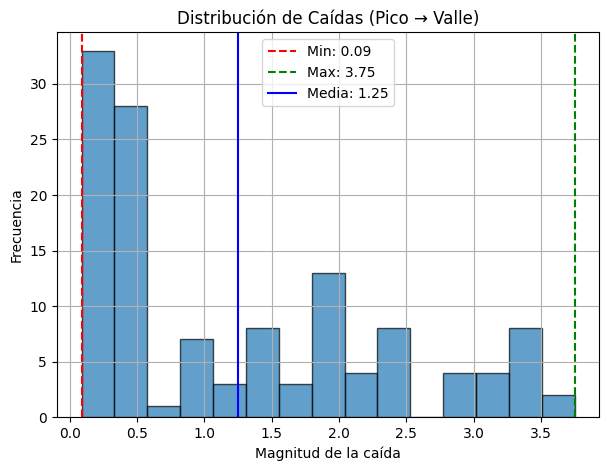

In [ ]:
#@title Caidas Pico → Valle
min_val = np.min(ptv_drop_all)
max_val = np.max(ptv_drop_all)
mean_val = np.mean(ptv_drop_all)

plt.figure(figsize=(7,5))

plt.hist(ptv_drop_all, bins=15, alpha=0.7, edgecolor='black')

# líneas de referencia
plt.axvline(min_val, color='red', linestyle='--', label=f'Min: {min_val:.2f}')
plt.axvline(max_val, color='green', linestyle='--', label=f'Max: {max_val:.2f}')
plt.axvline(mean_val, color='blue', linestyle='-', label=f'Media: {mean_val:.2f}')


plt.title("Distribución de Caídas (Pico → Valle)")
plt.xlabel("Magnitud de la caída")
plt.ylabel("Frecuencia")

plt.legend()
plt.grid(True)
plt.savefig(ruta+"caidas_ptv_valid.png")

plt.show()

###Valle → Pico

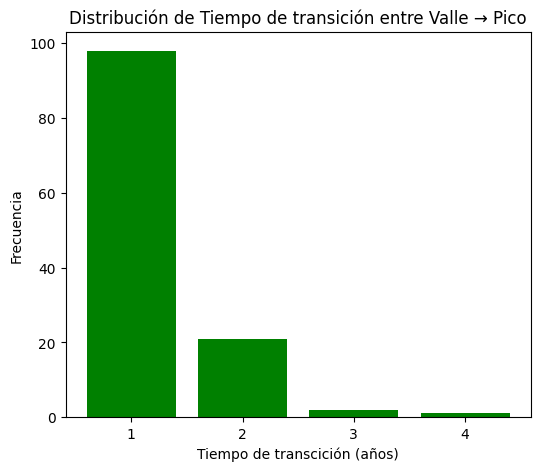

In [ ]:
#@title Tiempo  Valle → Pico
# Contar frecuencias
frecuencias = Counter(vtp_time_all)

# Separar valores y conteos
valores = list(frecuencias.keys())
conteos = list(frecuencias.values())

# Crear gráfico de barras
plt.figure(figsize=(6,5))

plt.bar(valores, conteos, color='green')

plt.title("Distribución de Tiempo de transición entre Valle → Pico")
plt.xlabel("Tiempo de transcición (años)")
plt.ylabel("Frecuencia")
plt.xticks(valores)
plt.savefig(ruta+"tiempo_vtp_valid.png")

plt.show()

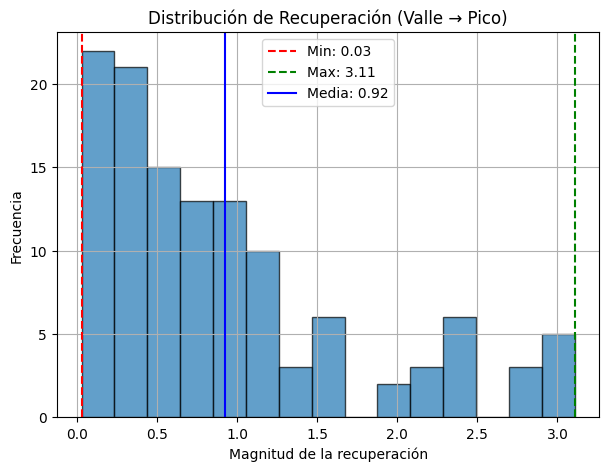

In [ ]:
#@title Recuperación Valle → Pico
min_val = np.min(vtp_rise_all)
max_val = np.max(vtp_rise_all)
mean_val = np.mean(vtp_rise_all)

plt.figure(figsize=(7,5))

plt.hist(vtp_rise_all, bins=15, alpha=0.7, edgecolor='black')

# líneas de referencia
plt.axvline(min_val, color='red', linestyle='--', label=f'Min: {min_val:.2f}')
plt.axvline(max_val, color='green', linestyle='--', label=f'Max: {max_val:.2f}')
plt.axvline(mean_val, color='blue', linestyle='-', label=f'Media: {mean_val:.2f}')


plt.title("Distribución de Recuperación (Valle → Pico)")
plt.xlabel("Magnitud de la recuperación")
plt.ylabel("Frecuencia")

plt.legend()
plt.grid(True)
plt.savefig(ruta+"recup_vtp_valid.png")

plt.show()

##Test

Cambio shape

In [ ]:
print(x_total_test.shape)
X = x_total_test.squeeze(-1)
print(X.shape)

(68, 10, 1)
(68, 10)


In [ ]:
ptv_time_all = []
vtp_time_all = []
ptv_drop_all = []
vtp_rise_all = []

for row in X:
    ptv_t, vtp_t, ptv_d, vtp_r = extract_dynamics(row)

    ptv_time_all.extend(ptv_t)
    vtp_time_all.extend(vtp_t)
    ptv_drop_all.extend(ptv_d)
    vtp_rise_all.extend(vtp_r)

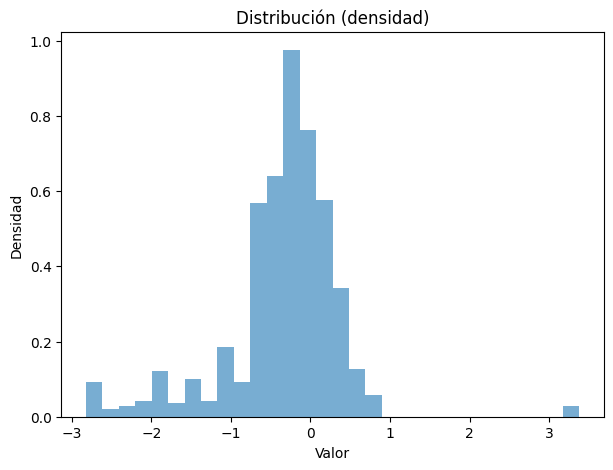

In [ ]:
#@title Distribución
all_values = X.flatten()

plt.figure(figsize=(7,5))

plt.hist(all_values, bins=30, density=True, alpha=0.6)

plt.title("Distribución (densidad)")
plt.xlabel("Valor")
plt.ylabel("Densidad")
plt.savefig(ruta+"densidad_test.png")

plt.show()

###Pico → Valle

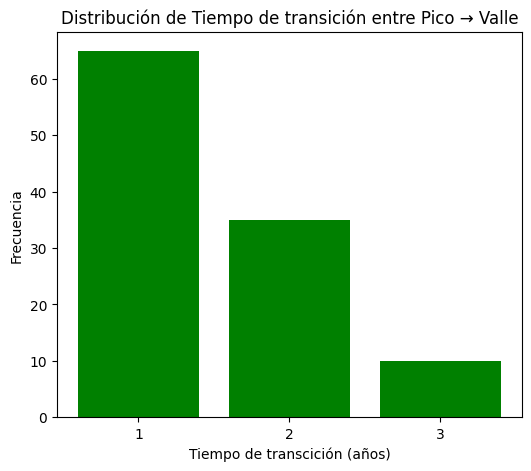

In [ ]:
#@title Tiempo Pico → Valle
# Contar frecuencias
frecuencias = Counter(ptv_time_all)

# Separar valores y conteos
valores = list(frecuencias.keys())
conteos = list(frecuencias.values())

# Crear gráfico de barras
plt.figure(figsize=(6,5))

plt.bar(valores, conteos, color='green')

plt.title("Distribución de Tiempo de transición entre Pico → Valle")
plt.xlabel("Tiempo de transcición (años)")
plt.ylabel("Frecuencia")
plt.xticks(valores)
plt.savefig(ruta+"tiempo_ptv_test.png")

plt.show()

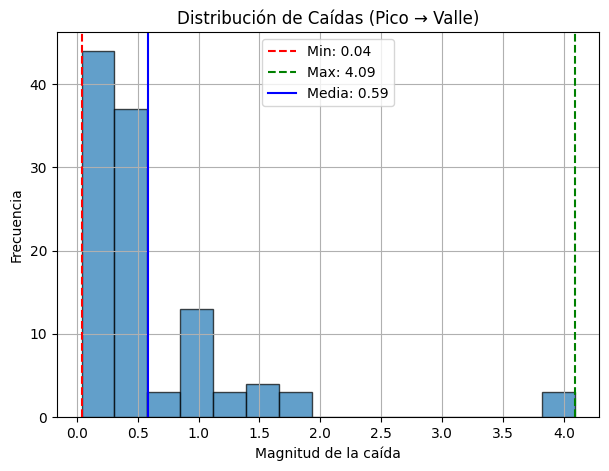

In [ ]:
#@title Caidas Pico → Valle
min_val = np.min(ptv_drop_all)
max_val = np.max(ptv_drop_all)
mean_val = np.mean(ptv_drop_all)

plt.figure(figsize=(7,5))

plt.hist(ptv_drop_all, bins=15, alpha=0.7, edgecolor='black')

# líneas de referencia
plt.axvline(min_val, color='red', linestyle='--', label=f'Min: {min_val:.2f}')
plt.axvline(max_val, color='green', linestyle='--', label=f'Max: {max_val:.2f}')
plt.axvline(mean_val, color='blue', linestyle='-', label=f'Media: {mean_val:.2f}')


plt.title("Distribución de Caídas (Pico → Valle)")
plt.xlabel("Magnitud de la caída")
plt.ylabel("Frecuencia")

plt.legend()
plt.grid(True)
plt.savefig(ruta+"caidas_ptv_test.png")

plt.show()

###Valle → Pico

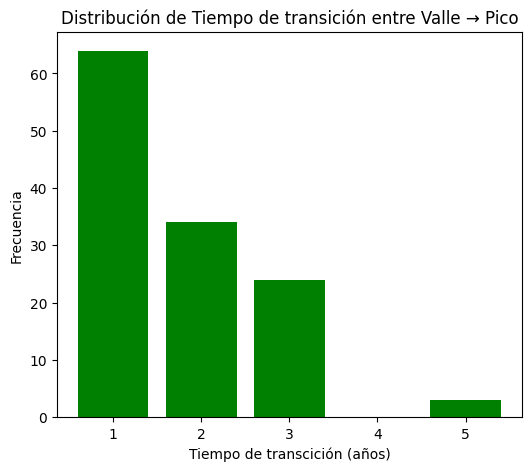

In [ ]:
#@title Tiempo  Valle → Pico
# Contar frecuencias
frecuencias = Counter(vtp_time_all)

# Separar valores y conteos
valores = list(frecuencias.keys())
conteos = list(frecuencias.values())

# Crear gráfico de barras
plt.figure(figsize=(6,5))

plt.bar(valores, conteos, color='green')

plt.title("Distribución de Tiempo de transición entre Valle → Pico")
plt.xlabel("Tiempo de transcición (años)")
plt.ylabel("Frecuencia")
#plt.xticks(valores)
plt.savefig(ruta+"tiempo_vtp_test.png")

plt.show()

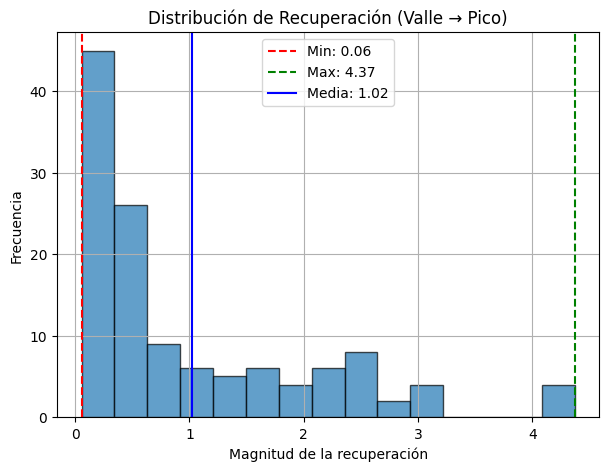

In [ ]:
#@title Recuperación Valle → Pico
min_val = np.min(vtp_rise_all)
max_val = np.max(vtp_rise_all)
mean_val = np.mean(vtp_rise_all)

plt.figure(figsize=(7,5))

plt.hist(vtp_rise_all, bins=15, alpha=0.7, edgecolor='black')

# líneas de referencia
plt.axvline(min_val, color='red', linestyle='--', label=f'Min: {min_val:.2f}')
plt.axvline(max_val, color='green', linestyle='--', label=f'Max: {max_val:.2f}')
plt.axvline(mean_val, color='blue', linestyle='-', label=f'Media: {mean_val:.2f}')


plt.title("Distribución de Recuperación (Valle → Pico)")
plt.xlabel("Magnitud de la recuperación")
plt.ylabel("Frecuencia")

plt.legend()
plt.grid(True)
plt.savefig(ruta+"recup_vtp_test.png")

plt.show()

#Cusp Catastrophe

La funcion potencial utilizada e inspirada en la catastrofe de cuspide es:

$$V(x;a_1,a_2,a_3)=a_1x^4+a_2x^2+a_3x$$

Donde los coeficientes $a_1,a_2$ y $a_3$ se expresan de la siguiente manera:

- $a_1$

$$a_1(t)=\frac{1}{4}F_1$$
- $a_2$

$$a_2(t)=\frac{1}{2}F_2\left(a_2^1+a_2^2t\right)$$

- $a_3$

Este coeficiente puede tener dos tipos de representaciones:


1. $$a_3(t)=a_3^1\sin(a_3^2t)$$
2. $$a_3(t)=a_3^1\cos(a_3^2t)$$

Los coeficientes: $F_1,F_2,a_2^1,a_2^2,a_3^1$ y $a_3^2$ son constantes.

Por lo tanto, se evaluan las siguientes configuraciones:
- $F_1=[0.5;1.0;5.0]$
- $F_2=[0.5;1.0;5.0]$
- $a_2^1=[-0.1;-0.4;-0.7;-1.0]$
- $a_2^2=[0.001;0.01;0.1;0.5;1.0]$
- $a_3^1=[0.1;0.5;1.0;3.0]$
- $a_3^2=[0.01;0.05;0.1]$

Adicionalmente, se consideran las siguientes condiciones iniciales:

$$x[0]=[-0.7;-0.4;-0.1;0.1;0.4;0.7]$$


##Funciones

In [ ]:
#Parametros dinamicos
def a(t,a_1,a_2):
  return a_1+a_2*t

def b(t,b_1,b_2,func):
  if func=="sin":
    return b_1*np.sin(b_2*t)
  elif func=="cos":
    return b_1*np.cos(b_2*t)
  elif func=="sinh":
    return b_1*np.sinh(b_2*t)
  elif func=="cosh":
    return b_1*np.cosh(b_2*t)

# Ecuación diferencial

def f(t,x,f_1,f_2,a_1,a_2,b_1,b_2,func):
  return -(f_1*x[0]**3+f_2*a(t,a_1,a_2)*x[0]+b(t,b_1,b_2,func))

##Parametros

In [ ]:
#Parametros de funciones
a_1=[-0.1,-0.4,-0.7,-1.0]
a_2=[0.001,0.01,0.1,0.5,1.0]
b_1=[0.1,0.5,1.0,3.0]
b_2=[0.01,0.05,0.1]
func=["sin","cos"]
f_1=[0.5,1.0,5.0]
f_2=[0.5,1.0,5.0]

# Intervalo de tiempo
t_span = (0, 100)

# Condición inicial
cond_ini = [-0.7,-0.4,-0.1,0.1,0.4,0.7]

#Anos que quiero crear
ano_pa=total

#Numero de anos para evitar tener series completamente estacionarias (ya que necesito variacion)
window_size = 6


##Generacion de datos sinteticos

In [ ]:
resultados = []
resultados_pik_val_1=[]
resultados_pik_val_2=[]
resultados_pik_val_3=[]
resultados_pik_val_4=[]
resultados_pik_val_5=[]
resultados_pik_val_6=[]
resultados_pik_val_7=[]
resultados_pik_val_8=[]
resultados_pik_val_9=[]

In [ ]:
pik_val_1=0 #peak=0 y val=0
pik_val_2=0 #peak=1 y val=0
pik_val_3=0 #peak=0 y val=1
pik_val_4=0 #peak=1 y val=1
pik_val_5=0 #peak=2 y val=0
pik_val_6=0 #peak=0 y val=2
pik_val_7=0 #peak=2 y val=1
pik_val_8=0 #peak=1 y val=2
pik_val_9=0 #peak=2 y val=2

contt=0

for co_a_1 in a_1:
  for co_a_2 in a_2:
    for co_b_1 in b_1:
      for co_b_2 in b_2:
        for co_func in func:
          for co_f_1 in f_1:
            for co_f_2 in f_2:
              for co_cond_ini in cond_ini:

                #Imprimir cada 10 000
                contt+=1
                if contt%10000==0:
                  print(contt)

                x0=[co_cond_ini]

                # Solver con paso adaptativo (RK45)
                sol = solve_ivp(
                    f,
                    t_span,
                    x0,
                    method='RK45',
                    args=(co_f_1,co_f_2,co_a_1,co_a_2,co_b_1,co_b_2,co_func),
                    rtol=1e-6,   # tolerancia relativa
                    atol=1e-9    # tolerancia absoluta
                )

                #Creo serie
                tiem=sol.t
                pib=sol.y[0]

                #Me quedo solo con 13 datos (saco un promedio)
                pib_promedio = []
                saltos=int(len(tiem)/ano_pa)
                for i in range(0, len(pib), saltos):
                    pib_promedio.append(np.mean(pib[i:i+saltos]))

                #Corregir tiempo
                dif=len(pib_promedio)-ano_pa
                if len(pib_promedio)!=ano_pa:
                  pib_promedio = pib_promedio[:-dif]

                #Pikos y valles
                peaks = []
                valleys = []

                x=pib_promedio

                for i in range(1, len(x)-1):
                    if x[i] > x[i-1] and x[i] > x[i+1]:
                        peaks.append(i)
                    elif x[i] < x[i-1] and x[i] < x[i+1]:
                        valleys.append(i)

                #Identificar si en la serie existen anos de no cambios significativos
                co_esta=0
                for i in range(len(x) - window_size + 1):
                    window = x[i:i+window_size]
                    diffs = np.abs(np.diff(window))
                    if np.all(diffs < 0.01):
                        co_esta+=1

                #Verificar Rango de la serie
                minimo=np.min(pib_promedio)
                maximo=np.max(pib_promedio)

                #Verificar requisitos
                ##Requisito de picos y valles
                if len(peaks) < 3 and len(valleys) < 3:
                  ##Requisito de estacionariedad
                  if co_esta == 0:
                    ##Requisito de intervalo (-3.5 a 3.5)
                    if minimo > -3.5 and maximo < 3.5:
                      resultados.append(pib_promedio)

                      #Contabilizar
                      if len(peaks)==0 and len(valleys)==0:
                        pik_val_1+=1
                        resultados_pik_val_1.append(pib_promedio)
                      elif len(peaks)==1 and len(valleys)==0:
                        pik_val_2+=1
                        resultados_pik_val_2.append(pib_promedio)
                      elif len(peaks)==0 and len(valleys)==1:
                        pik_val_3+=1
                        resultados_pik_val_3.append(pib_promedio)
                      elif len(peaks)==1 and len(valleys)==1:
                        pik_val_4+=1
                        resultados_pik_val_4.append(pib_promedio)
                      elif len(peaks)==2 and len(valleys)==0:
                        pik_val_5+=1
                        resultados_pik_val_5.append(pib_promedio)
                      elif len(peaks)==0 and len(valleys)==2:
                        pik_val_6+=1
                        resultados_pik_val_6.append(pib_promedio)
                      elif len(peaks)==2 and len(valleys)==1:
                        pik_val_7+=1
                        resultados_pik_val_7.append(pib_promedio)
                      elif len(peaks)==1 and len(valleys)==2:
                        pik_val_8+=1
                        resultados_pik_val_8.append(pib_promedio)
                      elif len(peaks)==2 and len(valleys)==2:
                        pik_val_9+=1
                        resultados_pik_val_9.append(pib_promedio)

10000
20000


In [ ]:
base_array=np.array(resultados)
base_pik_val_1=np.array(resultados_pik_val_1)
base_pik_val_2=np.array(resultados_pik_val_2)
base_pik_val_3=np.array(resultados_pik_val_3)
base_pik_val_4=np.array(resultados_pik_val_4)
base_pik_val_5=np.array(resultados_pik_val_5)
base_pik_val_6=np.array(resultados_pik_val_6)
base_pik_val_7=np.array(resultados_pik_val_7)
base_pik_val_8=np.array(resultados_pik_val_8)
base_pik_val_9=np.array(resultados_pik_val_9)

In [ ]:
print("peak=0 y val=0:",pik_val_1)
print("peak=1 y val=0:",pik_val_2)
print("peak=0 y val=1:",pik_val_3)
print("peak=1 y val=1:",pik_val_4)
print("peak=2 y val=0:",pik_val_5)
print("peak=0 y val=2:",pik_val_6)
print("peak=2 y val=1:",pik_val_7)
print("peak=1 y val=2:",pik_val_8)
print("peak=2 y val=2:",pik_val_9)

peak=0 y val=0: 886
peak=1 y val=0: 1627
peak=0 y val=1: 2977
peak=1 y val=1: 4136
peak=2 y val=0: 0
peak=0 y val=2: 0
peak=2 y val=1: 1184
peak=1 y val=2: 2987
peak=2 y val=2: 192


In [ ]:
base_array.shape

(13989, 13)

In [ ]:
#Cambiamos a otro formato
data_reshaped = base_array.reshape(base_array.shape[0], base_array.shape[1], 1)

In [ ]:
data_reshaped.shape

(13989, 13, 1)

#Guardar arrays

In [ ]:
np.save(ruta+'data_reshaped.npy', data_reshaped)
np.save(ruta+'base_pik_val_1', base_pik_val_1)
np.save(ruta+'base_pik_val_2', base_pik_val_2)
np.save(ruta+'base_pik_val_3', base_pik_val_3)
np.save(ruta+'base_pik_val_4', base_pik_val_4)
#np.save(ruta+'base_pik_val_5', base_pik_val_5)
#np.save(ruta+'base_pik_val_6', base_pik_val_6)
np.save(ruta+'base_pik_val_7', base_pik_val_7)
np.save(ruta+'base_pik_val_8', base_pik_val_8)
np.save(ruta+'base_pik_val_9', base_pik_val_9)

#Guardar parametros

In [ ]:
config = {
    "inicio": inicio,
    "final": final,
}

with open(ruta+"periodo.json", "w") as f:
    json.dump(config, f)


#Graficos de datos sinteticos

Cambio shape

In [ ]:
print(data_reshaped.shape)
X = data_reshaped.squeeze(-1)
print(X.shape)

(13989, 13, 1)
(13989, 13)


In [ ]:
ptv_time_all = []
vtp_time_all = []
ptv_drop_all = []
vtp_rise_all = []

for row in X:
    ptv_t, vtp_t, ptv_d, vtp_r = extract_dynamics(row)

    ptv_time_all.extend(ptv_t)
    vtp_time_all.extend(vtp_t)
    ptv_drop_all.extend(ptv_d)
    vtp_rise_all.extend(vtp_r)

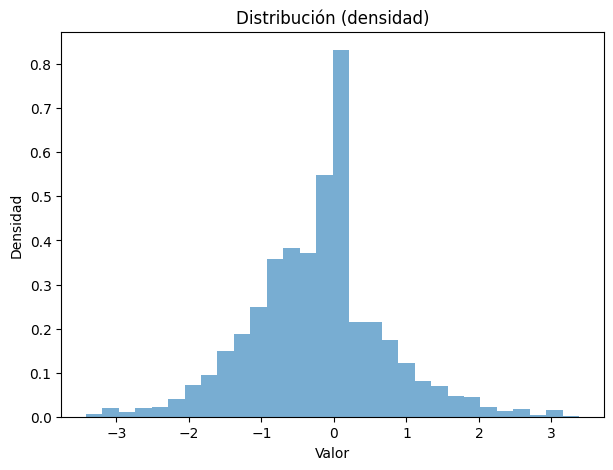

In [ ]:
#@title Distribución
all_values = X.flatten()

plt.figure(figsize=(7,5))

plt.hist(all_values, bins=30, density=True, alpha=0.6)

plt.title("Distribución (densidad)")
plt.xlabel("Valor")
plt.ylabel("Densidad")
plt.savefig(ruta+"densidad_dat_sintet.png")

plt.show()

###Pico → Valle

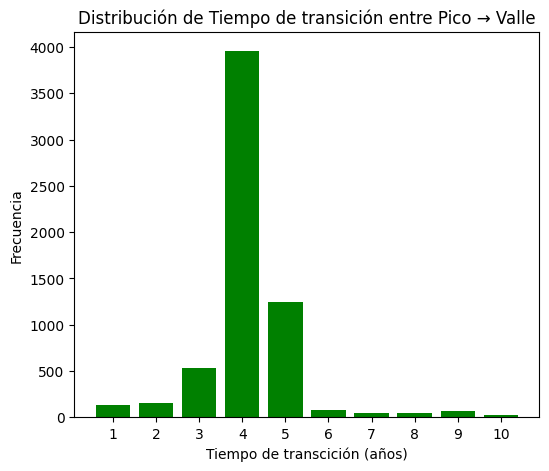

In [ ]:
#@title Tiempo Pico → Valle
# Contar frecuencias
frecuencias = Counter(ptv_time_all)

# Separar valores y conteos
valores = list(frecuencias.keys())
conteos = list(frecuencias.values())

# Crear gráfico de barras
plt.figure(figsize=(6,5))

plt.bar(valores, conteos, color='green')

plt.title("Distribución de Tiempo de transición entre Pico → Valle")
plt.xlabel("Tiempo de transcición (años)")
plt.ylabel("Frecuencia")
plt.xticks(valores)
plt.savefig(ruta+"tiempo_ptv_dat_sintet.png")

plt.show()

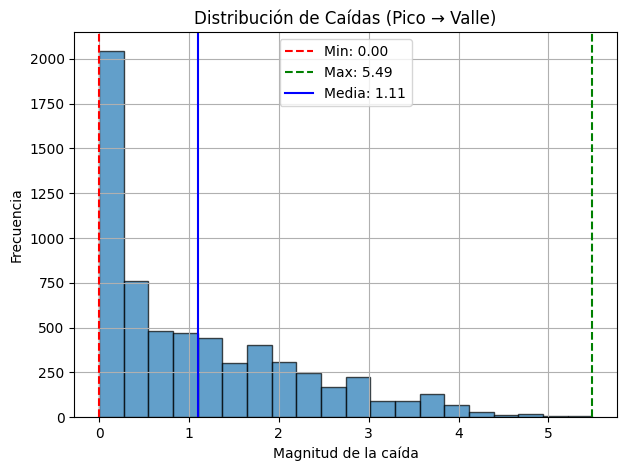

In [ ]:
#@title Caidas Pico → Valle
min_val = np.min(ptv_drop_all)
max_val = np.max(ptv_drop_all)
mean_val = np.mean(ptv_drop_all)

plt.figure(figsize=(7,5))

plt.hist(ptv_drop_all, bins=20, alpha=0.7, edgecolor='black')

# líneas de referencia
plt.axvline(min_val, color='red', linestyle='--', label=f'Min: {min_val:.2f}')
plt.axvline(max_val, color='green', linestyle='--', label=f'Max: {max_val:.2f}')
plt.axvline(mean_val, color='blue', linestyle='-', label=f'Media: {mean_val:.2f}')


plt.title("Distribución de Caídas (Pico → Valle)")
plt.xlabel("Magnitud de la caída")
plt.ylabel("Frecuencia")

plt.legend()
plt.grid(True)
plt.savefig(ruta+"caidas_ptv_dat_sintet.png")

plt.show()

###Valle → Pico

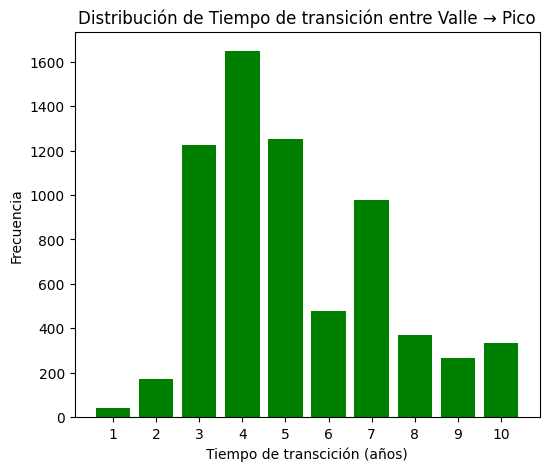

In [ ]:
#@title Tiempo  Valle → Pico
# Contar frecuencias
frecuencias = Counter(vtp_time_all)

# Separar valores y conteos
valores = list(frecuencias.keys())
conteos = list(frecuencias.values())

# Crear gráfico de barras
plt.figure(figsize=(6,5))

plt.bar(valores, conteos, color='green')

plt.title("Distribución de Tiempo de transición entre Valle → Pico")
plt.xlabel("Tiempo de transcición (años)")
plt.ylabel("Frecuencia")
plt.xticks(valores)
plt.savefig(ruta+"tiempo_vtp_dat_sintet.png")

plt.show()

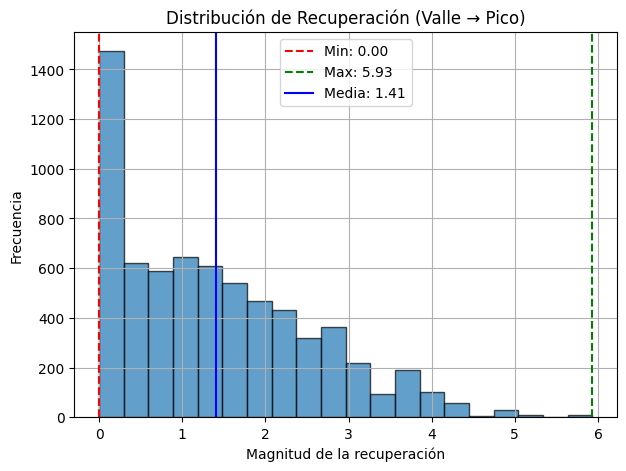

In [ ]:
#@title Recuperación Valle → Pico
min_val = np.min(vtp_rise_all)
max_val = np.max(vtp_rise_all)
mean_val = np.mean(vtp_rise_all)

plt.figure(figsize=(7,5))

plt.hist(vtp_rise_all, bins=20, alpha=0.7, edgecolor='black')

# líneas de referencia
plt.axvline(min_val, color='red', linestyle='--', label=f'Min: {min_val:.2f}')
plt.axvline(max_val, color='green', linestyle='--', label=f'Max: {max_val:.2f}')
plt.axvline(mean_val, color='blue', linestyle='-', label=f'Media: {mean_val:.2f}')


plt.title("Distribución de Recuperación (Valle → Pico)")
plt.xlabel("Magnitud de la recuperación")
plt.ylabel("Frecuencia")

plt.legend()
plt.grid(True)
plt.savefig(ruta+"recup_vtp_dat_sintet.png")

plt.show()